# Flat-Field correction statistics

In [1]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Some matplotlib parameters for "cool" visualization :)
plt.rcParams.update({
    "font.family": "serif",      
    "font.size": 10,             
    "axes.titlesize": 11,        
    "axes.labelsize": 10,        
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# All figures will be exported in
path2exp = Path("ffc_analysis") # Specify your directory to export
path2exp.mkdir(parents=True, exist_ok=True)

# Visualization helpers
from skimage.exposure import equalize_hist, rescale_intensity

def percentile_eq(image, p_low=2, p_high=98):
    """
    Contrast stretching based on percentiles p_low and p_high.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image (any numeric dtype).
    p_low : float
        Lower percentile (default = 2).
    p_high : float
        Upper percentile (default = 98).

    Returns
    -------
    np.ndarray
        Image rescaled after percentile stretching.
    """
    img = image.astype(np.float32)

    # Compute percentiles
    p2, p98 = np.percentile(img, (p_low, p_high))

    # Stretch
    img_stretched = rescale_intensity(img, in_range=(p2, p98))

    return img_stretched

In [2]:
from shimexpy import load_image

# Load test images
reference_img = load_image("../tests/example_data/flat.tif")
sample_img = load_image("../tests/example_data/smp.tif")
bright_img = load_image("../tests/example_data/bright.tif")
dark_img = load_image("../tests/example_data/dark.tif")

from shimexpy import crop

# y0, y1, x0, x1 = crop(sample_img)

# reference_img = reference_img[y0:y1 , x0:x1]
# sample_img = sample_img[y0:y1 , x0:x1]
# bright_img = bright_img[y0:y1 , x0:x1]
# dark_img = dark_img[y0:y1 , x0:x1]

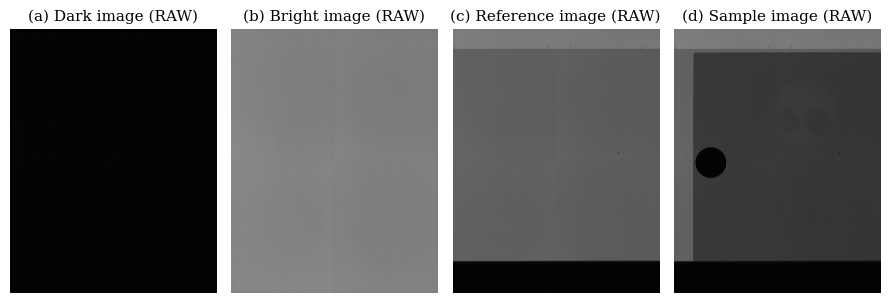

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(9, 4))

axes[0].imshow(dark_img, cmap="gray")
axes[0].set_title("(a) Dark image (RAW)")
axes[0].axis("off")

axes[1].imshow(bright_img, cmap="gray")
axes[1].set_title("(b) Bright image (RAW)")
axes[1].axis("off")

axes[2].imshow(reference_img, cmap="gray")
axes[2].set_title("(c) Reference image (RAW)")
axes[2].axis("off")

axes[3].imshow(sample_img, cmap="gray")
axes[3].set_title("(d) Sample image (RAW)")
axes[3].axis("off")

fig.tight_layout()

In [4]:
fig.savefig(path2exp / "raw_images.png")

In [5]:
from shimexpy import crop

y0, y1, x0, x1 = crop(sample_img)

In [6]:
reference_img_roi = reference_img[y0:y1 , x0:x1]
sample_img_roi = sample_img[y0:y1 , x0:x1]
bright_img_roi = bright_img[y0:y1 , x0:x1]
dark_img_roi = dark_img[y0:y1 , x0:x1]

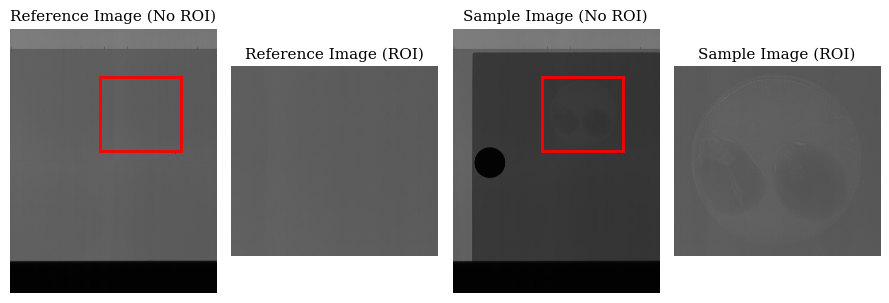

In [7]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 4, figsize=(9, 4))

width = x1 - x0
height = y1 - y0

rect1 = patches.Rectangle(
    (x0, y0),
    width, height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

rect2 = patches.Rectangle(
    (x0, y0),
    width, height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

axes[0].imshow(reference_img, cmap="gray")
axes[0].set_title("Reference Image (No ROI)")
axes[0].axis("off")

axes[0].add_patch(rect1)

axes[1].imshow(reference_img_roi, cmap="gray")
axes[1].set_title("Reference Image (ROI)")
axes[1].axis("off")

axes[2].imshow(sample_img, cmap="gray")
axes[2].set_title("Sample Image (No ROI)")
axes[2].axis("off")

axes[2].add_patch(rect2)

axes[3].imshow(sample_img_roi, cmap="gray")
axes[3].set_title("Sample Image (ROI)")
axes[3].axis("off")

fig.tight_layout()

In [8]:
fig.savefig(path2exp / "raw_and_roi_images.png")

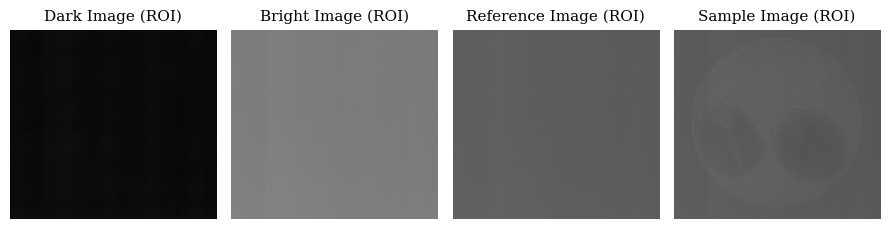

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(9, 4))

axes[0].imshow(dark_img_roi, cmap="gray")
axes[0].set_title("Dark Image (ROI)")
axes[0].axis("off")

axes[1].imshow(bright_img_roi, cmap="gray")
axes[1].set_title("Bright Image (ROI)")
axes[1].axis("off")

axes[2].imshow(reference_img_roi, cmap="gray")
axes[2].set_title("Reference Image (ROI)")
axes[2].axis("off")

axes[3].imshow(sample_img_roi, cmap="gray")
axes[3].set_title("Sample Image (ROI)")
axes[3].axis("off")

fig.tight_layout()

In [10]:
fig.savefig(path2exp / "roi_images.png")

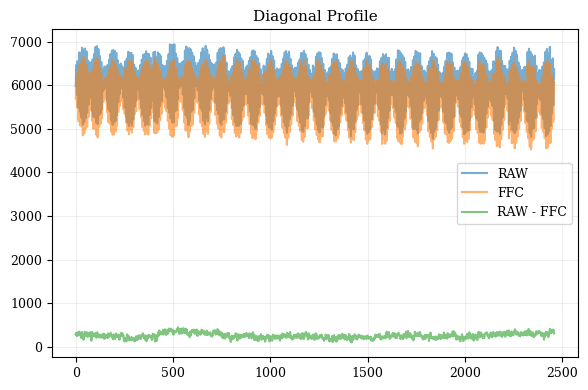

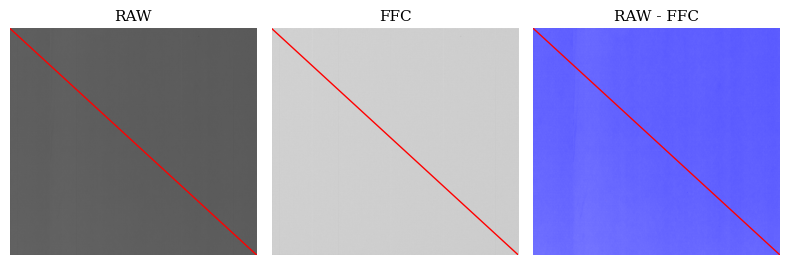

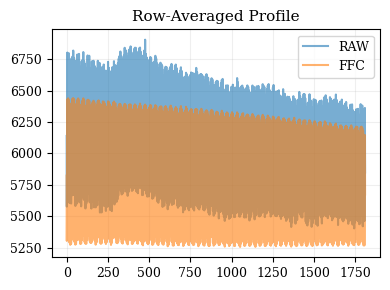

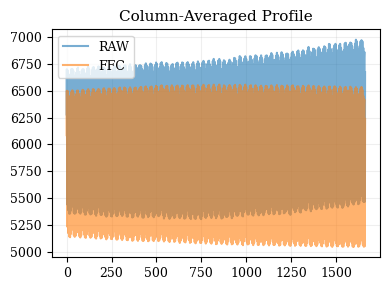

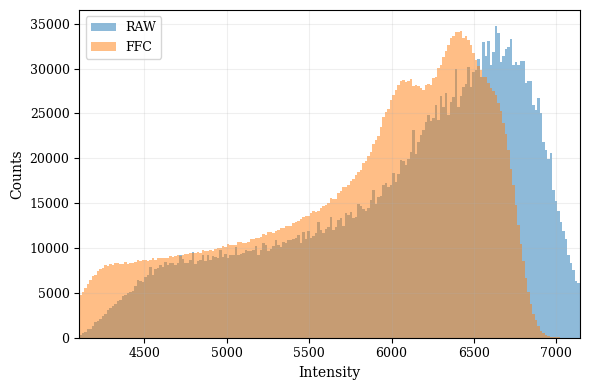

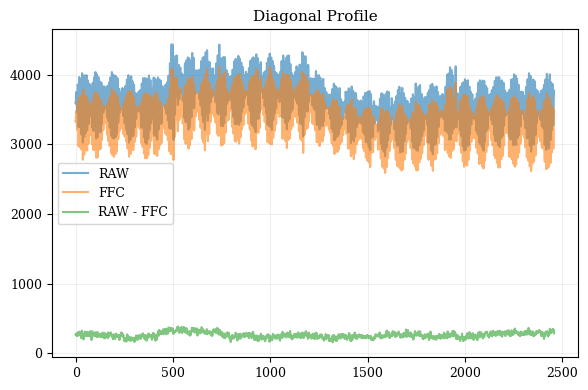

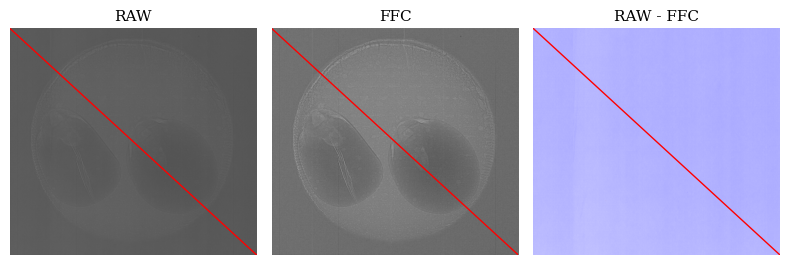

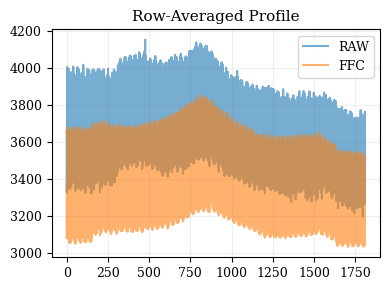

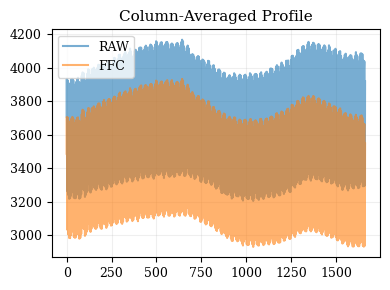

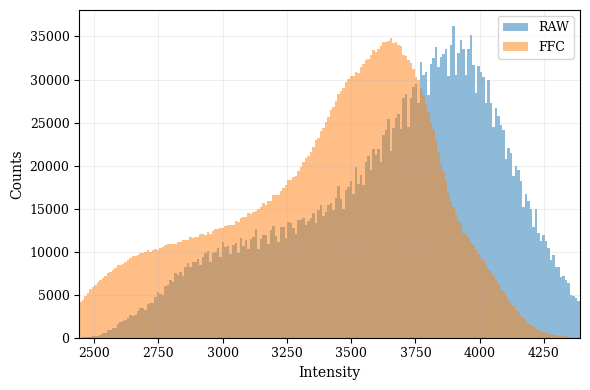

In [11]:
# SHIMEXPY: main processing functions
from shimexpy import ffc, FFCQualityAssessment
import time

reference_ffc = ffc(reference_img_roi, dark_img_roi, bright_img_roi)
sample_ffc = ffc(sample_img_roi, dark_img_roi, bright_img_roi)

# For reference
assessor_ref = FFCQualityAssessment(reference_img_roi, reference_ffc)
report_ref = assessor_ref.report()
fig1_ref = assessor_ref.plot_images()
fig2_ref, fig3_ref = assessor_ref.plot_profiles()
fig4_ref = assessor_ref.plot_histograms()

# For sample
assessor_smp = FFCQualityAssessment(sample_img_roi, sample_ffc)
report_smp = assessor_smp.report()
fig1_smp = assessor_smp.plot_images()
fig2_smp, fig3_smp = assessor_smp.plot_profiles()
fig4_smp = assessor_smp.plot_histograms()

In [12]:
report_ref['2D_stats']

{'mean_raw': 6064.779296875,
 'mean_ffc': 5796.80126953125,
 'std_raw': 733.6389770507812,
 'std_ffc': 725.5064697265625,
 'ptp_raw': 15972.0,
 'ptp_ffc': 10393.6826171875,
 'std_reduction_%': 1.1085162564441873,
 'ptp_reduction_%': 34.925603448613195,
 'nu_raw': 0.12096713518145723,
 'nu_ffc': 0.12515634674935638}

In [13]:
fig1_ref[0].savefig(path2exp / "ref_roi_imgs_comp_images.png")
fig1_ref[1].savefig(path2exp / "ref_roi_imgs_comp_profiles.png")
fig2_ref.savefig(path2exp / "ref_roi_row_profile.png")
fig3_ref.savefig(path2exp / "ref_roi_col_profile.png")
fig4_ref.savefig(path2exp / "ref_roi_hist_profile.png")

fig1_smp[0].savefig(path2exp / "smp_roi_imgs_comp_images.png")
fig1_smp[1].savefig(path2exp / "smp_roi_imgs_comp_profiles.png")
fig2_smp.savefig(path2exp / "smp_roi_row_profile.png")
fig3_smp.savefig(path2exp / "smp_roi_col_profile.png")
fig4_smp.savefig(path2exp / "smp_roi_hist_profile.png")

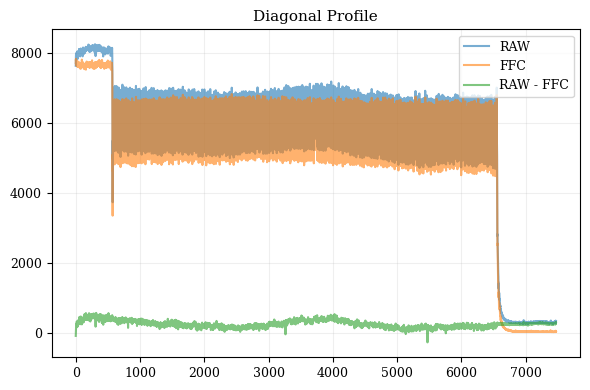

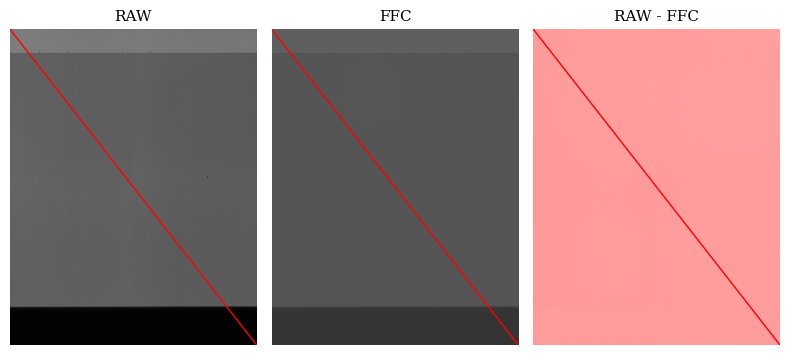

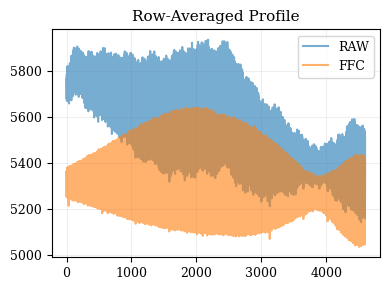

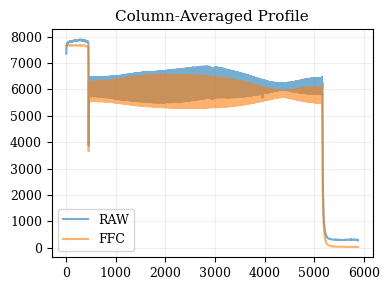

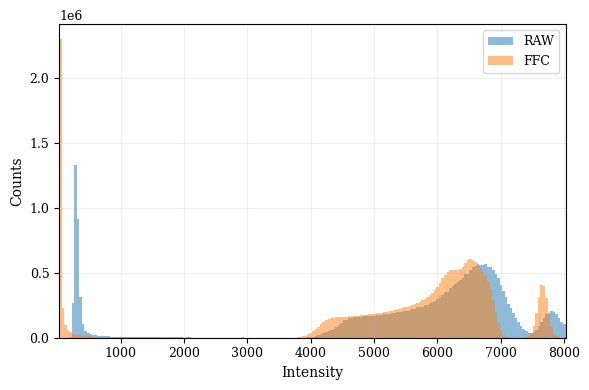

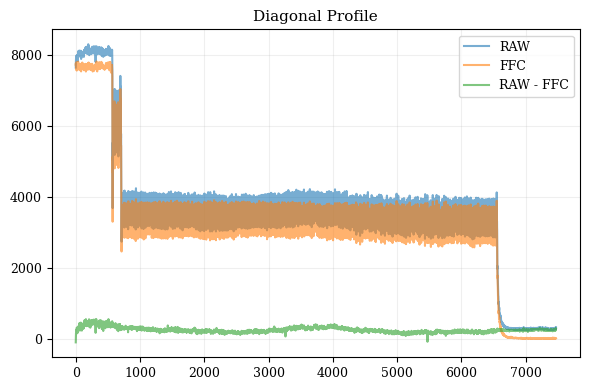

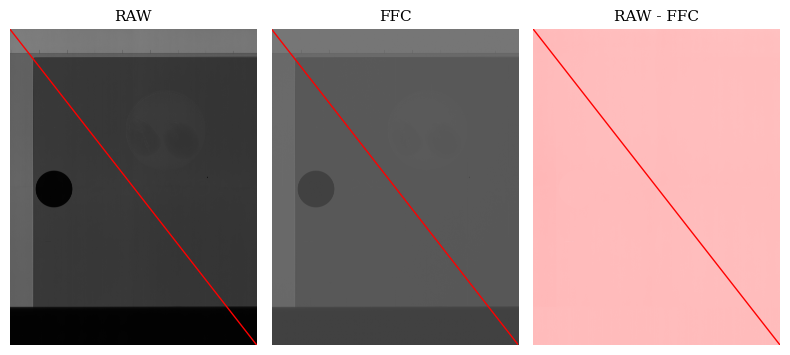

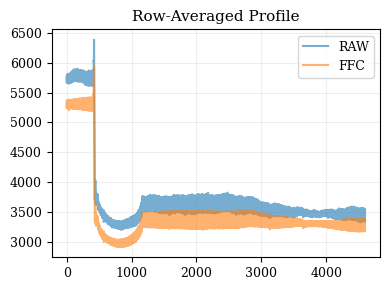

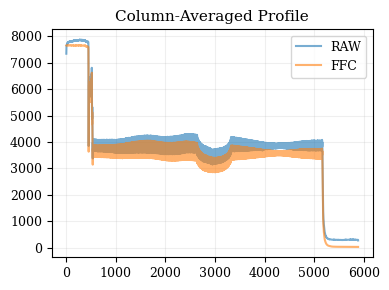

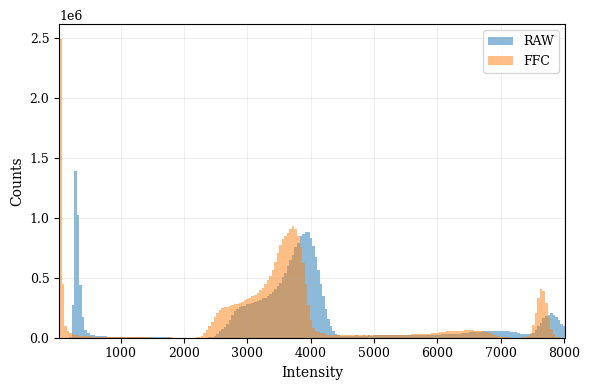

In [14]:
ref_no_roi_ffc = ffc(reference_img, dark_img, bright_img)
smp_no_roi_ffc = ffc(sample_img, dark_img, bright_img)

# For reference
assessor_ref_no_roi = FFCQualityAssessment(reference_img, ref_no_roi_ffc)
report_ref_no_roi = assessor_ref_no_roi.report()
fig1_ref_no_roi = assessor_ref_no_roi.plot_images()
fig2_ref_no_roi, fig3_ref_no_roi = assessor_ref_no_roi.plot_profiles()
fig4_ref_no_roi = assessor_ref_no_roi.plot_histograms()

# For sample
assessor_smp_no_roi = FFCQualityAssessment(sample_img, smp_no_roi_ffc)
report_smp_no_roi = assessor_smp_no_roi.report()
fig1_smp_no_roi = assessor_smp_no_roi.plot_images()
fig2_smp_no_roi, fig3_smp_no_roi = assessor_smp_no_roi.plot_profiles()
fig4_smp_no_roi = assessor_smp_no_roi.plot_histograms()

In [15]:
report_ref_no_roi["2D_stats"]

{'mean_raw': 5562.49267578125,
 'mean_ffc': 5317.2060546875,
 'std_raw': 2100.521240234375,
 'std_ffc': 2107.697998046875,
 'ptp_raw': 16281.0,
 'ptp_ffc': 45668.703125,
 'std_reduction_%': -0.34166556733790615,
 'ptp_reduction_%': -180.50305954793933,
 'nu_raw': 0.377622293217556,
 'nu_ffc': 0.39639201045985184}

In [16]:
fig1_ref_no_roi[0].savefig(path2exp / "ref_no_roi_imgs_comp_images.png")
fig1_ref_no_roi[1].savefig(path2exp / "ref_no_roi_imgs_comp_profile.png")
fig2_ref_no_roi.savefig(path2exp / "ref_no_roi_row_profile.png")
fig3_ref_no_roi.savefig(path2exp / "ref_no_roi_col_profile.png")
fig4_ref_no_roi.savefig(path2exp / "ref_no_roi_hist_profile.png")

fig1_smp_no_roi[0].savefig(path2exp / "smp_no_roi_imgs_comp_images.png")
fig1_smp_no_roi[1].savefig(path2exp / "smp_no_roi_imgs_comp_profile.png")
fig2_smp_no_roi.savefig(path2exp / "smp_no_roi_row_profile.png")
fig3_smp_no_roi.savefig(path2exp / "smp_no_roi_col_profile.png")
fig4_smp_no_roi.savefig(path2exp / "smp_no_roi_hist_profile.png")

In [17]:
from shimexpy import get_harmonics, get_contrast, get_contrasts

ref_abs_ffc, ref_scat_ffc, ref_dpc_ffc, ref_block_grid_ffc = get_harmonics(
    reference_ffc,
    projected_grid=5
)

abs_contrast_ffc, scat_contrast_ffc, dpc_contrast_ffc = get_contrasts(
    sample_ffc,
    (ref_abs_ffc, ref_scat_ffc, ref_dpc_ffc),
    ref_block_grid_ffc
)

In [18]:
ref_abs, ref_scat, ref_dpc, ref_block_grid = get_harmonics(
    reference_img_roi,
    projected_grid=5
)

abs_contrast, scat_contrast, dpc_contrast = get_contrasts(
    sample_img_roi,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid
)

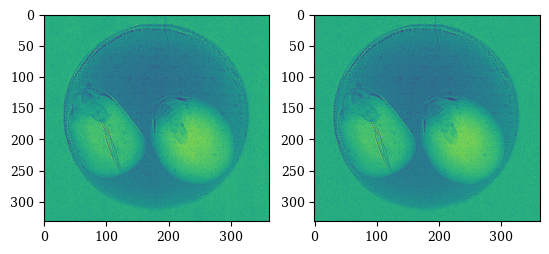

In [19]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(abs_contrast)
ax[1].imshow(abs_contrast_ffc)

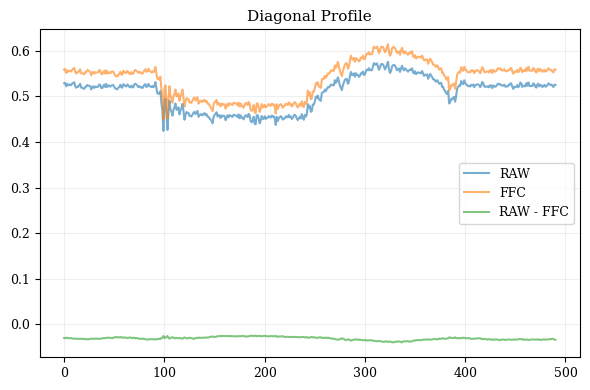

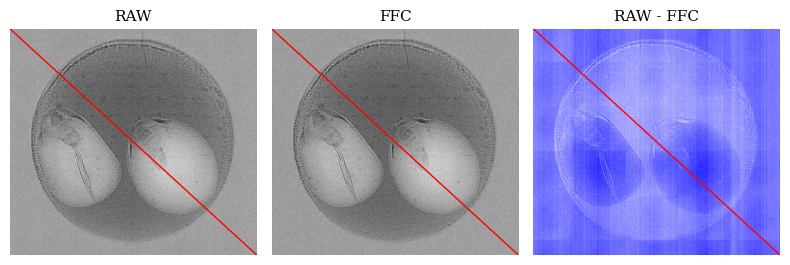

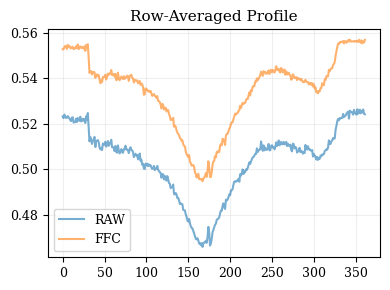

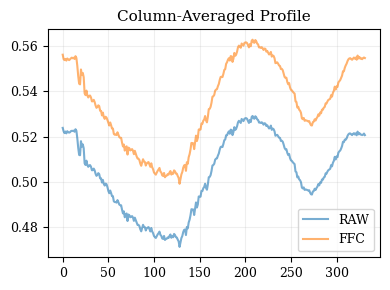

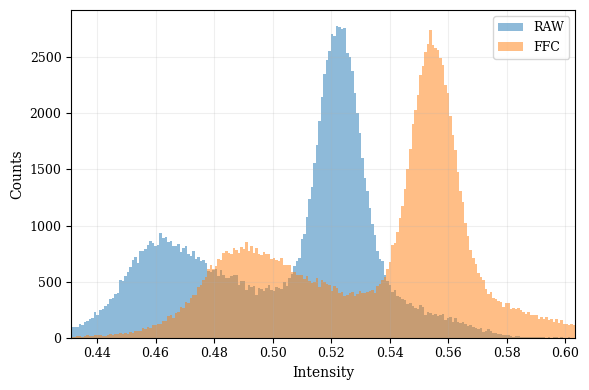

In [20]:
# For reference
assessor = FFCQualityAssessment(abs_contrast.values, abs_contrast_ffc.values)
report = assessor.report()
fig1 = assessor.plot_images()
fig2, fig3 = assessor.plot_profiles()
fig4 = assessor.plot_histograms()

In [21]:
report["2D_stats"]

{'mean_raw': 0.5038742423057556,
 'mean_ffc': 0.5346776843070984,
 'std_raw': 0.031922757625579834,
 'std_ffc': 0.034444041550159454,
 'ptp_raw': 0.2967548370361328,
 'ptp_ffc': 0.32126617431640625,
 'std_reduction_%': -7.898076833309994,
 'ptp_reduction_%': -8.25979368191021,
 'nu_raw': 0.06335461300720509,
 'nu_ffc': 0.06442019661769934}

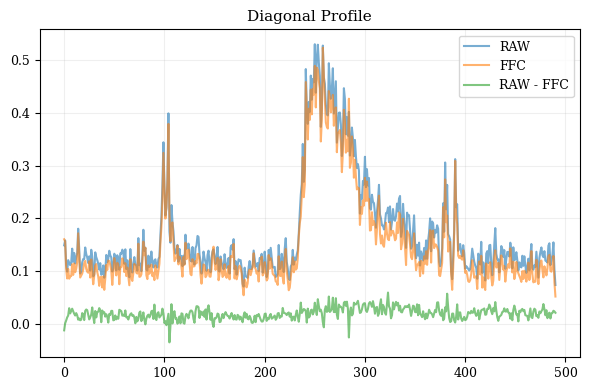

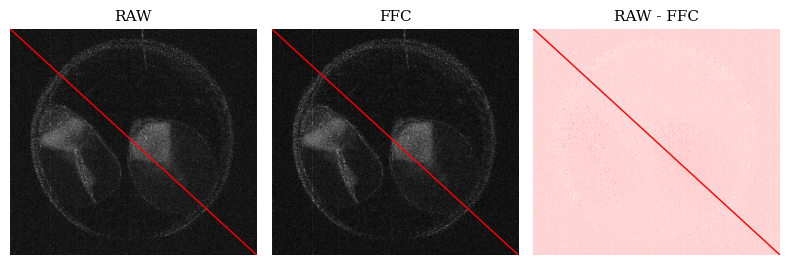

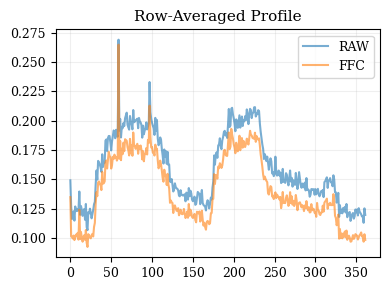

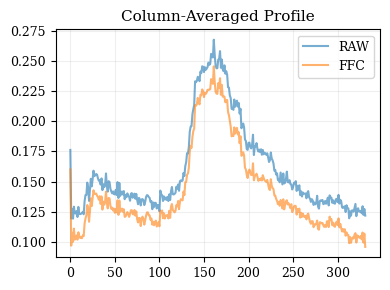

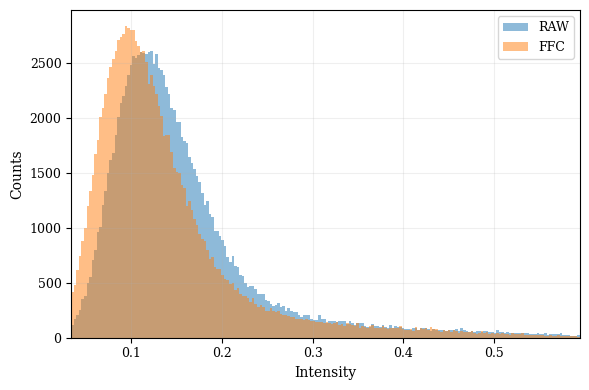

In [22]:
# For reference
assessor = FFCQualityAssessment(scat_contrast.values, scat_contrast_ffc.values)
report = assessor.report()
fig1 = assessor.plot_images()
fig2, fig3 = assessor.plot_profiles()
fig4 = assessor.plot_histograms()

In [23]:
report["2D_stats"]

{'mean_raw': 0.15973564982414246,
 'mean_ffc': 0.14106421172618866,
 'std_raw': 0.0959206148982048,
 'std_ffc': 0.09345655143260956,
 'ptp_raw': 1.365237832069397,
 'ptp_ffc': 1.2879996299743652,
 'std_reduction_%': 2.568857036842621,
 'ptp_reduction_%': 5.657490605717818,
 'nu_raw': 0.6004959757186736,
 'nu_ffc': 0.6625107125967039}

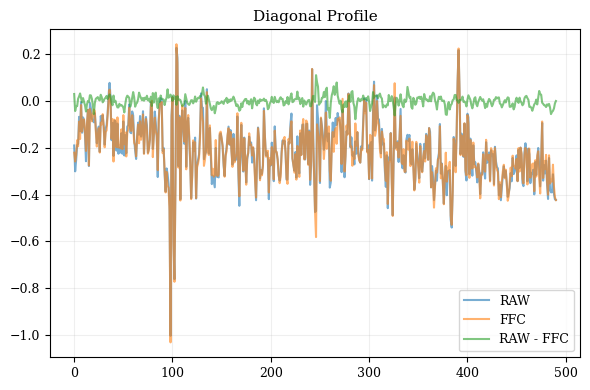

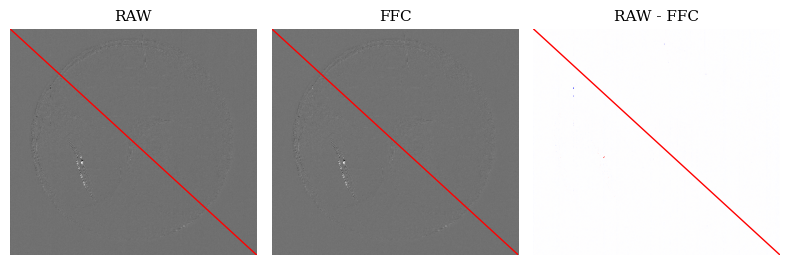

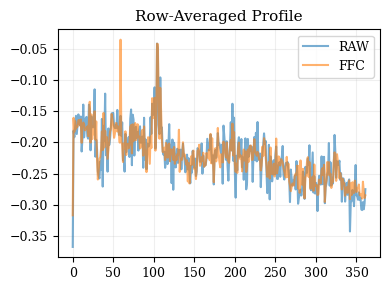

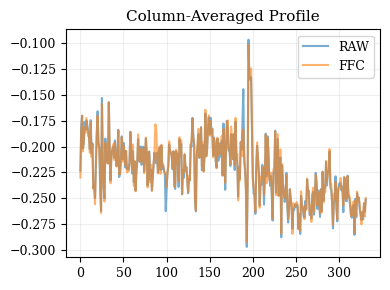

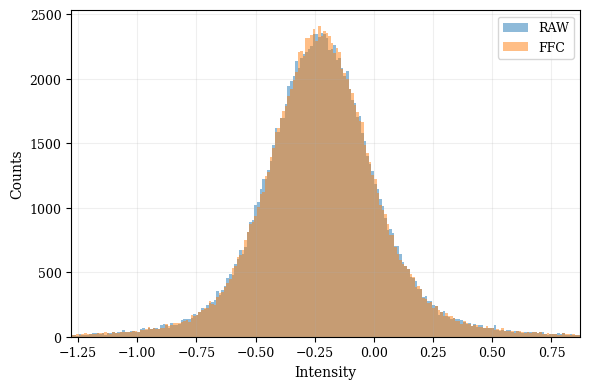

In [24]:
# For reference
assessor = FFCQualityAssessment(dpc_contrast.values, dpc_contrast_ffc.values)
report = assessor.report()
fig1 = assessor.plot_images()
fig2, fig3 = assessor.plot_profiles()
fig4 = assessor.plot_histograms()

In [25]:
report["2D_stats"]

{'mean_raw': -0.22282001376152039,
 'mean_ffc': -0.22216260433197021,
 'std_raw': 0.35500794649124146,
 'std_ffc': 0.35118329524993896,
 'ptp_raw': 24.90115737915039,
 'ptp_ffc': 25.083484649658203,
 'std_reduction_%': 1.0773424310931163,
 'ptp_reduction_%': -0.7322040005275987,
 'nu_raw': -1.5932498185338013,
 'nu_ffc': -1.580748912743107}